In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
movies = pd.read_csv("../dataset/tmdb_5000_movies.csv")
credits = pd.read_csv("../dataset/tmdb_5000_credits.csv")

print("Movies shape:", movies.shape)
print("Credits shape:", credits.shape)

Movies shape: (4803, 20)
Credits shape: (4803, 4)


In [3]:
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [4]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [5]:
print("Movie columns:")
print(movies.columns.tolist())

print("\nCredit columns:")
print(credits.columns.tolist())

Movie columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Credit columns:
['movie_id', 'title', 'cast', 'crew']


In [6]:
credits = credits.rename(columns={"movie_id": "id"})

In [7]:
movies = movies.merge(
    credits,
    on="id"
)

print("Merged dataset shape:", movies.shape)

Merged dataset shape: (4803, 23)


In [11]:
movies = movies[
    [
        "id",
        "title_x",
        "overview",
        "genres",
        "keywords",
        "cast",
        "crew"
    ]
].copy()

In [12]:
movies.head()

,id,title_x,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [13]:
print(movies.isnull().sum())

id          0
title_x     0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64


In [14]:
movies["overview"] = movies["overview"].fillna("")

In [15]:
print(movies.isnull().sum())

id          0
title_x     0
overview    0
genres      0
keywords    0
cast        0
crew        0
dtype: int64


In [16]:
def extract_names(text):
    try:
        data = ast.literal_eval(text)
        return [item["name"] for item in data]
    except:
        return []

In [17]:
movies["genres"] = movies["genres"].apply(extract_names)

In [19]:
print(movies.columns.tolist())

['id', 'title_x', 'overview', 'genres', 'keywords', 'cast', 'crew']


In [20]:
movies = movies.rename(columns={"title_x": "title"})

In [21]:
print(movies.columns.tolist())

['id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']


In [22]:
movies[["title", "genres"]].head()

,title,genres
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]"
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]"
2,Spectre,"[Action, Adventure, Crime]"
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]"
4,John Carter,"[Action, Adventure, Science Fiction]"


In [24]:
movies["keywords"] = movies["keywords"].apply(extract_names)

In [25]:
movies[["title", "keywords"]].head()

,title,keywords
0,Avatar,"[culture clash, future, space war, space colon..."
1,Pirates of the Caribbean: At World's End,"[ocean, drug abuse, exotic island, east india ..."
2,Spectre,"[spy, based on novel, secret agent, sequel, mi..."
3,The Dark Knight Rises,"[dc comics, crime fighter, terrorist, secret i..."
4,John Carter,"[based on novel, mars, medallion, space travel..."


In [26]:
def extract_cast(text):
    try:
        data = ast.literal_eval(text)
        return [item["name"] for item in data[:5]]
    except:
        return []

In [27]:
movies["cast"] = movies["cast"].apply(extract_cast)

In [28]:
movies[["title", "cast"]].head()

,title,cast
0,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weave..."
1,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley, ..."
2,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R..."
3,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman, A..."
4,John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton,..."


In [29]:
movies["overview"] = movies["overview"].apply(
    lambda x: x.lower().split()
)

In [30]:
movies["genres"] = movies["genres"].apply(
    lambda x: [i.lower().replace(" ", "") for i in x]
)

movies["keywords"] = movies["keywords"].apply(
    lambda x: [i.lower().replace(" ", "") for i in x]
)

movies["cast"] = movies["cast"].apply(
    lambda x: [i.lower().replace(" ", "") for i in x]
)

In [31]:
movies["tags"] = (
    movies["overview"]
    + movies["genres"]
    + movies["keywords"]
    + movies["cast"]
)

In [32]:
movies["tags"] = movies["tags"].apply(
    lambda x: " ".join(x)
)

In [33]:
movies[["title", "tags"]].head()

,title,tags
0,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,Spectre,a cryptic message from bond’s past sends him o...
3,The Dark Knight Rises,following the death of district attorney harve...
4,John Carter,"john carter is a war-weary, former military ca..."


In [34]:
movies = movies[
    ["id", "title", "tags"]
].copy()

In [35]:
movies.head()

,id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


In [36]:
print(movies.shape)

(4803, 3)


In [37]:
movies.to_csv(
    "../results/movies_prepared.csv",
    index=False
)

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [39]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [40]:
tfidf_matrix = tfidf.fit_transform(movies["tags"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (4803, 5000)


In [41]:
from sklearn.metrics.pairwise import cosine_similarity

In [42]:
cosine_sim = cosine_similarity(tfidf_matrix)

print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (4803, 4803)


In [43]:
movie_indices = pd.Series(
    movies.index,
    index=movies["title"]
).drop_duplicates()

In [44]:
movie_indices["Avatar"]

np.int64(0)

In [45]:
def recommend_movies(title, num_recommendations=10):
    
    if title not in movie_indices:
        return f"Movie '{title}' not found in the dataset."
    
    idx = movie_indices[title]
    
    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )
    
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    similarity_scores = similarity_scores[1:num_recommendations + 1]
    
    movie_indices_list = [
        i[0] for i in similarity_scores
    ]
    
    recommendations = movies.iloc[
        movie_indices_list
    ][["title"]].copy()
    
    recommendations["Similarity"] = [
        round(i[1], 4) for i in similarity_scores
    ]
    
    return recommendations.reset_index(drop=True)

In [46]:
recommend_movies("Avatar")

,title,Similarity
0,Falcon Rising,0.2000
1,Battle: Los Angeles,0.1941
2,Apollo 18,0.1797
3,Star Trek Into Darkness,0.1623
4,Titan A.E.,0.1546
5,Jarhead,0.1539
6,Lifeforce,0.1526
7,Aliens,0.1518
8,Galaxina,0.1507
9,Ender's Game,0.1494


In [47]:
recommend_movies("The Dark Knight")

,title,Similarity
0,The Dark Knight Rises,0.4338
1,Batman Returns,0.3696
2,Batman Begins,0.3369
3,"Batman: The Dark Knight Returns, Part 2",0.3027
4,Batman Forever,0.2808
5,Batman v Superman: Dawn of Justice,0.2536
6,Batman & Robin,0.2229
7,Batman,0.1866
8,The Lego Movie,0.1350
9,Superman,0.1348


In [48]:
recommend_movies("Titanic")

,title,Similarity
0,Ghost Ship,0.2178
1,Poseidon,0.2083
2,In the Heart of the Sea,0.1978
3,The Bounty,0.1915
4,Captain Phillips,0.1887
5,Pirates of the Caribbean: On Stranger Tides,0.1818
6,The Black Hole,0.1812
7,Triangle,0.1804
8,"20,000 Leagues Under the Sea",0.1772
9,WALL·E,0.1653


In [49]:
avatar_recommendations = recommend_movies(
    "Avatar",
    10
)

avatar_recommendations.to_csv(
    "../results/avatar_recommendations.csv",
    index=False
)

avatar_recommendations

,title,Similarity
0,Falcon Rising,0.2000
1,Battle: Los Angeles,0.1941
2,Apollo 18,0.1797
3,Star Trek Into Darkness,0.1623
4,Titan A.E.,0.1546
5,Jarhead,0.1539
6,Lifeforce,0.1526
7,Aliens,0.1518
8,Galaxina,0.1507
9,Ender's Game,0.1494


In [50]:
test_movies = [
    "Avatar",
    "Titanic",
    "The Dark Knight"
]

for movie in test_movies:
    print("\nRecommendations for:", movie)
    print(recommend_movies(movie, 5))


Recommendations for: Avatar
                     title  Similarity
0            Falcon Rising      0.2000
1      Battle: Los Angeles      0.1941
2                Apollo 18      0.1797
3  Star Trek Into Darkness      0.1623
4               Titan A.E.      0.1546

Recommendations for: Titanic
                     title  Similarity
0               Ghost Ship      0.2178
1                 Poseidon      0.2083
2  In the Heart of the Sea      0.1978
3               The Bounty      0.1915
4         Captain Phillips      0.1887

Recommendations for: The Dark Knight
                                     title  Similarity
0                    The Dark Knight Rises      0.4338
1                           Batman Returns      0.3696
2                            Batman Begins      0.3369
3  Batman: The Dark Knight Returns, Part 2      0.3027
4                           Batman Forever      0.2808


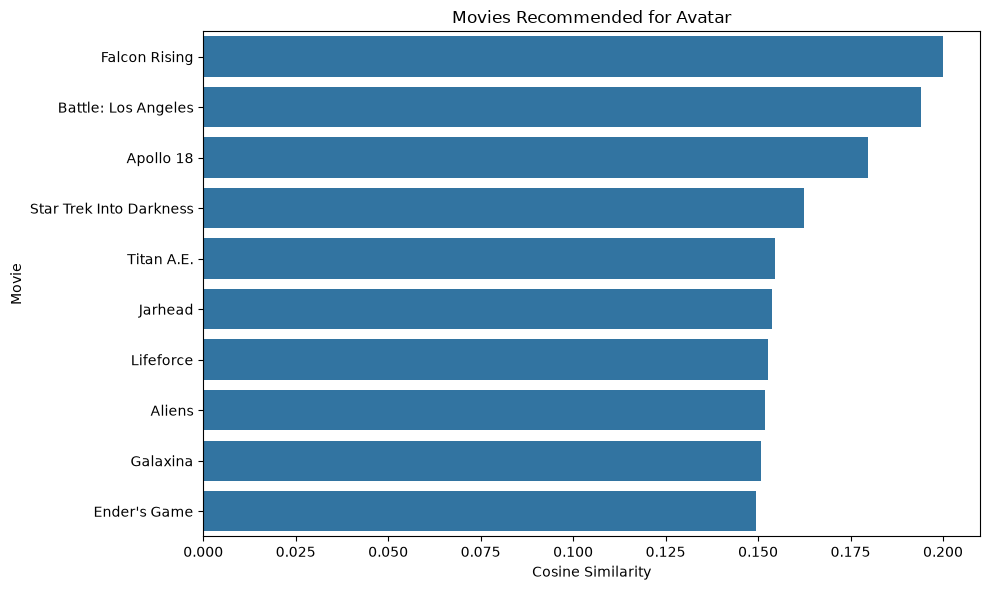

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=avatar_recommendations,
    x="Similarity",
    y="title"
)

plt.title("Movies Recommended for Avatar")
plt.xlabel("Cosine Similarity")
plt.ylabel("Movie")

plt.tight_layout()

plt.savefig(
    "../results/avatar_recommendations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
def get_recommendations():
    
    movie_name = input("Enter a movie name: ")
    
    result = recommend_movies(
        movie_name,
        10
    )
    
    print("\nRecommended Movies:")
    print(result)

In [53]:
get_recommendations()

Enter a movie name:  Avatar



Recommended Movies:
                     title  Similarity
0            Falcon Rising      0.2000
1      Battle: Los Angeles      0.1941
2                Apollo 18      0.1797
3  Star Trek Into Darkness      0.1623
4               Titan A.E.      0.1546
5                  Jarhead      0.1539
6                Lifeforce      0.1526
7                   Aliens      0.1518
8                 Galaxina      0.1507
9             Ender's Game      0.1494


In [54]:
recommend_movies("Harry Potter XYZ")

"Movie 'Harry Potter XYZ' not found in the dataset."

In [55]:
movies_to_test = [
    "Avatar",
    "Titanic",
    "The Dark Knight"
]

all_recommendations = []

for movie in movies_to_test:
    
    result = recommend_movies(movie, 5)
    
    if isinstance(result, pd.DataFrame):
        result.insert(0, "Input_Movie", movie)
        all_recommendations.append(result)

recommendation_results = pd.concat(
    all_recommendations,
    ignore_index=True
)

recommendation_results

,Input_Movie,title,Similarity
0,Avatar,Falcon Rising,0.2000
1,Avatar,Battle: Los Angeles,0.1941
2,Avatar,Apollo 18,0.1797
3,Avatar,Star Trek Into Darkness,0.1623
4,Avatar,Titan A.E.,0.1546
5,Titanic,Ghost Ship,0.2178
6,Titanic,Poseidon,0.2083
7,Titanic,In the Heart of the Sea,0.1978
8,Titanic,The Bounty,0.1915
9,Titanic,Captain Phillips,0.1887


In [56]:
recommendation_results.to_csv(
    "../results/sample_recommendations.csv",
    index=False
)

In [57]:
import os

print("RESULT FILES:")
for file in sorted(os.listdir("../results")):
    print("✓", file)

RESULT FILES:
✓ avatar_recommendations.csv
✓ avatar_recommendations.png
✓ movies_prepared.csv
✓ sample_recommendations.csv
